In [75]:
import numpy as np
import matplotlib.pyplot as plt
import math
import mpmath as mp

# Code to calculate the mean of the Sackin index

In [76]:
# Reference formulas (Yule, uniform, max, min)

# Yule mean
def sackin_yule(n):
    return 2 * n * np.sum(1 / np.arange(2, n + 1))

# Maximum value
def max_sackin(n):
    return (n * (n + 1)) / 2 - 1

# Minimum value
def min_sackin(n):
    return math.floor(np.log2(n) - 1)*n + 3*n - 2**(math.floor(np.log2(n) - 1) + 2)


# Uniform model
def sackin_uniform(n):
    return n * (np.prod(np.arange(2*n - 2, 1, -2) / np.arange(2*n - 3, 0, -2)) - 1)

In [77]:
# Calculating the mean of the Sackin index under the biased speciation model using high-precision arithmetic
# Default precision: max(40, n/2) digits

# Returns the ej probabilities for constant p model as an array of length n-2
def constant_p_ej_stable(n, p):
    mp.mp.dps = max(40, n // 2)  # set decimal places
    return [mp.mpf(mp.mpf(p)**j + (mp.mpf(1 - p))**j - 1) for j in range(2, n-1)]

# Return the ej probabilities for beta(a,b) model as an array of length n-2
def beta_ej_stable(n, a, b):
    mp.mp.dps = max(40, n // 2)  # set decimal places

    ej = []
    for k in range(2, n-1):
        beta_moment_a = mp.gamma(mp.mpf(a) + (k - 1)) * mp.gamma(mp.mpf(a) + mp.mpf(b)) / (mp.gamma(mp.mpf(a)) * mp.gamma(mp.mpf(a) + mp.mpf(b) + (k - 1)))
        beta_moment_b = mp.gamma(mp.mpf(b) + (k - 1)) * mp.gamma(mp.mpf(a) + mp.mpf(b)) / (mp.gamma(mp.mpf(b)) * mp.gamma(mp.mpf(a) + mp.mpf(b) + (k - 1)))
        ej.append(beta_moment_a + beta_moment_b - mp.mpf(1))
    return ej

# Sum method with high-precision arithmetic
def sackin_mean_sum_stable(n, ej):
    # Corner case: n < 3
    if n < 3:
        return max_sackin(n)
    
    mp.mp.dps = max(40, n//2) # set decimal places
    
    total = mp.mpf((n*(n+1)) / 2 - 1)
    current = mp.mpf((n - 1) * (n - 2) / 2)
    for k in range(3, n):
        current *= mp.mpf(ej[k - 3]) * mp.mpf(n - k) / mp.mpf(k)
        total += current
    return total

# Constant p mean
def sackin_mean_const_p(n, p):
    return sackin_mean_sum_stable(n, constant_p_ej_stable(n, p))

# Beta mean
def sackin_mean_beta(n, a, b):
    return sackin_mean_sum_stable(n, beta_ej_stable(n, a, b))


In [ ]:
# Formula for the mean Sackin index under the biased speciation model

# Naive implementations (without high-precision arithmetic)

# Returns a vector of length n-2, where the j-th entry is the value of e_j
# for a constant lambda~p model
def constant_p_ej(n, p):
    return np.array([(p**j + (1 - p)**j - 1) for j in range(2, n-1)])

# Returns the k-th moment of a Beta(a,b) distribution
def beta_moment(k, a, b):
    return np.math.gamma(a + k) * np.math.gamma(a + b) / (np.math.gamma(a) * np.math.gamma(a + b + k))

# Returns a vector of length n-2, where the j-th entry is the value of e_j
# for a lambda~Beta(a,b) model
def beta_ej(n, a, b):
    return np.array([(beta_moment(j, a, b) + beta_moment(j, b, a) - 1) for j in range(2, n)])

# Mean Sackin index for a tree of size n under the biased speciation model using summation
def sackin_mean_sum(n, ej):
    total = (n*(n+1)) / 2 - 1
    current = (n - 1) * (n - 2) / 2
    for k in range(3, n):
        current *= ej[k - 3] * (n - k) / k
        total += current
    return total

# Mean Sackin index for a tree of size n under the biased speciation model using finite differences
def sackin_mean_fd(n, ej):
    if n < 3:
        return max_sackin(n)
    f = np.zeros(n)
    f[1] = -2
    f[2] = 1
    for k in range(3, n):
        f[k] = f[k - 1] * (ej[k - 3]) * (-1)

    # Do forward difference operator Delta^(n-1) on the vector f
    for _ in range(n-1):
        f = f[1:] - f[:-1]
    return (-1)**(n-1) * f[0]

# Mean for constant p
def sackin_constant_p(n, p):
    ej = constant_p_ej(n, p)
    return sackin_mean_fd(n, ej)

# Mean for Beta(a,b)
def sackin_beta(n, a, b):
    ej = beta_ej(n, a, b)
    return sackin_mean_fd(n, ej)

In [23]:
# High-precision implementations

def sackin_mean_const_p_stable(n, p, digits = 100):
    if n < 3:
        return max_sackin(n)
    
    mp.mp.dps = digits # set decimal places
    
    f = [mp.mpf(0)] * n
    f[1] = mp.mpf(-2)
    f[2] = mp.mpf(1)
    for k in range(3, n):
        ej = mp.mpf(mp.mpf(p)**(k-1) + (1 - mp.mpf(p))**(k-1) - 1)
        f[k] = f[k - 1] * ej * mp.mpf(-1)

    # Do forward difference operator Delta^(n-1) on the vector f
    for _ in range(n-1):
        f = [f[i+1] - f[i] for i in range(len(f)-1)]
    return (-1)**(n-1) * f[0]


def sackin_mean_beta_stable(n, a, b, digits = 100):
    if n < 3:
        return max_sackin(n)
    
    mp.mp.dps = digits # set decimal places
    
    f = [mp.mpf(0)] * n
    f[1] = mp.mpf(-2)
    f[2] = mp.mpf(1)
    for k in range(3, n):
        beta_moment_a = mp.gamma(mp.mpf(a) + (k - 1)) * mp.gamma(mp.mpf(a) + mp.mpf(b)) / (mp.gamma(mp.mpf(a)) * mp.gamma(mp.mpf(a) + mp.mpf(b) + (k - 1)))
        beta_moment_b = mp.gamma(mp.mpf(b) + (k - 1)) * mp.gamma(mp.mpf(a) + mp.mpf(b)) / (mp.gamma(mp.mpf(b)) * mp.gamma(mp.mpf(a) + mp.mpf(b) + (k - 1)))
        ej = beta_moment_a + beta_moment_b - mp.mpf(1)
        f[k] = f[k - 1] * ej * mp.mpf(-1)

    # Do forward difference operator Delta^(n-1) on the vector f
    for _ in range(n-1):
        f = [f[i+1] - f[i] for i in range(len(f)-1)]
    return (-1)**(n-1) * f[0]

In [22]:
# Verify that two ways of computing the mean give the same result (up to round-off error)

n = 40
p = 0.3

print("Sum method, p =", p, ": ", sackin_mean_sum(n, constant_p_ej(n, p)))
print("FD method, p =", p, ": ", sackin_mean_fd(n, constant_p_ej(n, p)))
print("High-precision FD method, p =", p, ": ", sackin_mean_const_p_stable(n, p, digits=n / 2))

Sum method, p = 0.3 :  238.2311907060422
FD method, p = 0.3 :  238.231190907078
High-precision FD method, p = 0.3 :  238.23119063752954129


In [24]:
# Detects when the high-precision computation stabilizes
n = 2000
p = 0.5

d = range(10, n, n//10)

for digits in d:
    print(digits, " digits: ", sackin_mean_const_p_stable(n, p, digits=digits))

10  digits:  1.267671059e+69
210  digits:  1.88541413042342537845924655315284229721865297364176480918816959469088030753742886911478587150009234059010360501391274211737130462662481077354270883960277981298111987103863727586318977748417164673223694303745807e+349
410  digits:  45340388413913415870511419177309333163433152587413942269019993055458409122423558711310354059788775939767990305023670250943297483677437305041276639965086627434261180415069127212399697404002.588001649764039421457807360339846097136463100690363836684677094928713925852311977395253781127108963758504381943708436658745039683303765607956962773657152315136628873158110450993539401213264376863165938815984688778994483931
610  digits:  22497.559116115038333826226858078764708051118409074048880658006818794717906976466976173256635334985426479278994530585837867347889317425016776435678267216436503037488666714965473434706469227611395188849403864553285202507320697731723314879002096341818726395837535249251671304236787272366493297834741000

In [25]:
# Repeat with a beta distribution
a = 100
b = 100
for digits in d:
    print(digits, " digits: ", sackin_mean_beta_stable(n, a, b, digits=digits))

10  digits:  1.398463362e+79
210  digits:  -2.46228702180641598060740287094648789860384294966622342529366359050594678120567032366118855866091473394535531233091860096989994778830562329444976240382631774213634120813192792673499182107273980999786947139810739e+388
410  digits:  131887813724471321766172987495124144848684507263213995026938473338892047888591498895352490893825987788475129223614123725386437604009188449336840077938518804684301553766941703019099308187663.00803895556735153494765857237879006341910326846366665331573483313584856889854709698506845449627323395594721943411906588186070697487440100052220230692569488585737726829415040597785881621409765027680818744212003646206550541
610  digits:  22557.85729521152470941585594697098154156174560904855016388739221497611985086190202194441494414280834477231068483365483151853625465634944213872147498878724352642648709267224606613703633163761818148746012450919587762756306724610863753410716474656788837904751227856320091507932058056176441701722636290

# Plotting the results

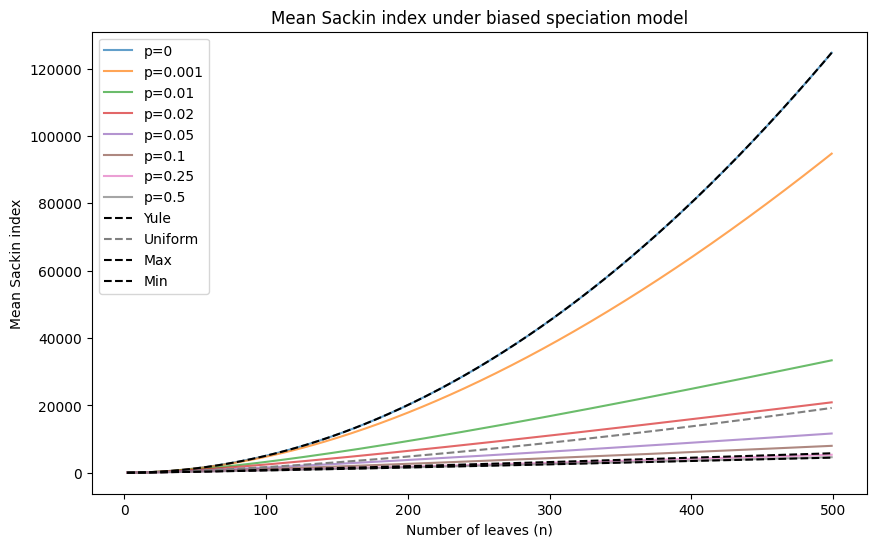

In [79]:
plt.figure(figsize=(10, 6))

p = [0, 0.001, 0.01, 0.02, 0.05, 0.1, 0.25, 0.5]


N = range(2, 500)
for prob in p:
    means = [sackin_mean_const_p(n, prob) for n in N]
    plt.plot(N, means, label=f"p={prob}", alpha = 0.7)

plt.plot(N, [sackin_yule(n) for n in N], label="Yule", linestyle='dashed', color='black')
plt.plot(N, [sackin_uniform(n) for n in N], label="Uniform", linestyle='dashed', color='gray')
plt.plot(N, [max_sackin(n) for n in N], label="Max", linestyle='dashed', color='black')
plt.plot(N, [min_sackin(n) for n in N], label="Min", linestyle='dashed', color='black')
plt.xlabel("Number of leaves (n)")
plt.ylabel("Mean Sackin index")
plt.title("Mean Sackin index under biased speciation model")
plt.legend()
plt.show()

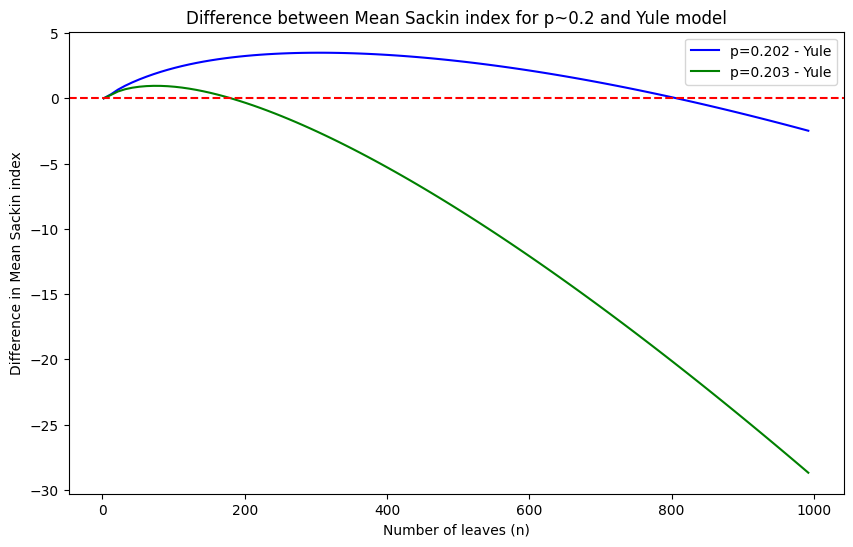

In [32]:
# Comparing the p=0.2 case to Yule

s1 = 0.202
s2 = 0.203
N = np.arange(2, 1000, 10)

diff = [sackin_mean_const_p_stable(n, s1, digits=max(20, n/2)) - sackin_yule(n) for n in N]
diff2 = [sackin_mean_const_p_stable(n, s2, digits=max(20, n/2)) - sackin_yule(n) for n in N]
plt.figure(figsize=(10, 6))
plt.plot(N, diff, label=f"p={s1} - Yule", color='blue')
plt.plot(N, diff2, label=f"p={s2} - Yule", color='green')
plt.axhline(0, color='red', linestyle='dashed')
plt.xlabel("Number of leaves (n)")
plt.ylabel("Difference in Mean Sackin index")
plt.title("Difference between Mean Sackin index for p~0.2 and Yule model")
plt.legend()
plt.show()

In [81]:
# Plot the yule mean, p=0.5, and minimum value
N = range(2, 5000, 50)

yule = [sackin_yule(n) for n in N]
p05 = [sackin_mean_const_p_stable(n, 0.5, digits= max(40, n//2)) for n in N]
minimum = [min_sackin(n) for n in N]

plt.figure(figsize=(10, 6))
plt.plot(N, yule, label="Yule", color='blue')  
plt.plot(N, p05, label="p=0.5", color='orange')
plt.plot(N, minimum, label="Minimum", color='green')
plt.xlabel("Number of leaves (n)")
plt.ylabel("Mean Sackin index")
plt.title("Mean Sackin index for Yule, p=0.5, and Minimum")
plt.legend()
plt.show()

KeyboardInterrupt: 

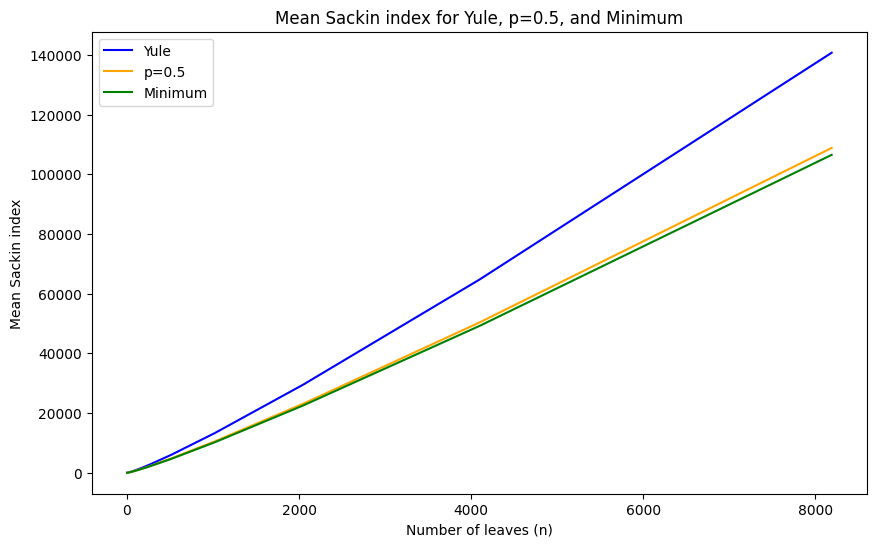

In [84]:
N = [2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192]

yule = [sackin_yule(n) for n in N]
p05 = [sackin_mean_const_p_stable(n, 0.5, digits= max(40, n//2)) for n in N]
minimum = [min_sackin(n) for n in N]

plt.figure(figsize=(10, 6))
plt.plot(N, yule, label="Yule", color='blue')  
plt.plot(N, p05, label="p=0.5", color='orange')
plt.plot(N, minimum, label="Minimum", color='green')
plt.xlabel("Number of leaves (n)")
plt.ylabel("Mean Sackin index")
plt.title("Mean Sackin index for Yule, p=0.5, and Minimum")
plt.legend()
plt.show()

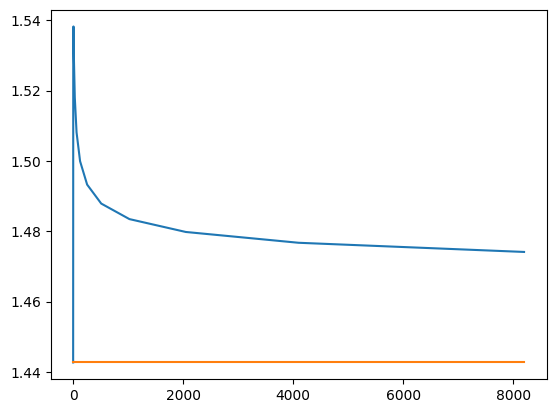

In [89]:
vals = np.array(p05)

plt.plot(N, vals/ np.log(np.array(N)) / np.array(N))
plt.plot(N, minimum/ np.log(np.array(N)) / np.array(N))

In [46]:
# Sum method with high-precision arithmetic
def sackin_mean_sum_stable(n, ej, digits=100):
    if n < 3:
        return max_sackin(n)
    
    mp.mp.dps = digits # set decimal places
    
    total = mp.mpf((n*(n+1)) / 2 - 1)
    current = mp.mpf((n - 1) * (n - 2) / 2)
    for k in range(3, n):
        current *= mp.mpf(ej[k - 3]) * mp.mpf(n - k) / mp.mpf(k)
        total += current
    return total

def constant_p_ej_stable(n, p, digits=100):
    mp.mp.dps = digits # set decimal places
    return [mp.mpf(mp.mpf(p)**j + (1 - mp.mpf(p))**j - 1) for j in range(2, n-1)]

In [47]:
sackin_mean_const_p_stable(100, 0.5, digits= 1000), sackin_mean_sum_stable(100, constant_p_ej_stable(1000, 0.5), digits= 1000)

(mpf('692.003462560849500696057922089040676555832952573249975316972848577383010601729674925952923920703800474217793315951868401108247263854402240945688645848652971137286425906828073031098366203076777376123672784845783592528888198813094238308034902442452097334318987067706724633278061973778188316218305896361234159069489018434927916560257368786399877544596270978354700967048947948845660726532943756739874884925632687849410998574845541956140672640390045083589880221202759032032725017753379644660753573410926945734872777813087021408833623343280475981023810811864539605489379860467383504005818320650266843471318387469101447622023865043249800654275817774732844838722400755841515199162264751702194063236442034197041487965238936229349804532562893725766261069615570444178294191848175726432227552039784719575998347354708002810567193093378540007024697030071795333023909096260010791682249284163365393793690429210296257757862282938379024832730005468755444150848274943767671797430445615375909415401560909690778993

In [49]:
n = 5000
sackin_mean_const_p_stable(n, 0.201, digits= n/2), sackin_yule(n)

(mpf('81009.6986187477493158517157246553129147264306010733485957469408792569549574673177520646130585841968515847276844437688446726077735643547501570667102427223313940420065049229034487532018390817983323531274996537424078329375204245716845744679270272105077662888347979839905084973049259781443950680404312340353095989060891901484153023125158400505892754468066751029932556890411659987312572196905076815191878134276976562903435910847498042734759169024410331216527280396411282526693851094796061336955732039374556636362180922616416670933341708692079927619863272836739764804301794056612034718581976143291560531739356614875960787847140635058434614415055411686126347303944683141409493664680788992831778969467721504073321956208365617177274887138277112894769947181506132372295598844326571493982508943117866956123743591758891905044934160610904778693513455150730513625516102547816842838439100112428946566788738898554526603640067246336450338378066063917244196840846569452399119907535182356701879716862376503462857

In [53]:
n = 5000
sackin_mean_sum_stable(n, constant_p_ej_stable(n, 0.201, digits=n/2), digits=n/2)

mpf('81009.69861874774931585171572465531291472643060107334859574694087925695495746731775206461305858419685158472768444376884467260777356435475015706671024272233139404200650492290344875320183908179833235312749965374240783293752042457168457446792702721050776628883479798399050849730492597814439506804043123403530959890608919014841530231251584005058927544680667510299325568904116599873125721969050768151918781342769765629034359108474980427347591690244103312165272803964112825266938510947960613369557320393745566363621809226164166709333417086920799276198632728367397648043017940566120347185819761432915605317393566148759607878471406350584346144150554116861263473039446831414094936646807889928317789694677215040733219562083656171772748871382771128947699471815061323722955988443265714939825089431178669561237435917588919050449341606109047786935134551507305136255161025478168428384391001124289465667887388985545266036400672463364503383780660639172441968408465694523991199075351823567018797168623765034628579

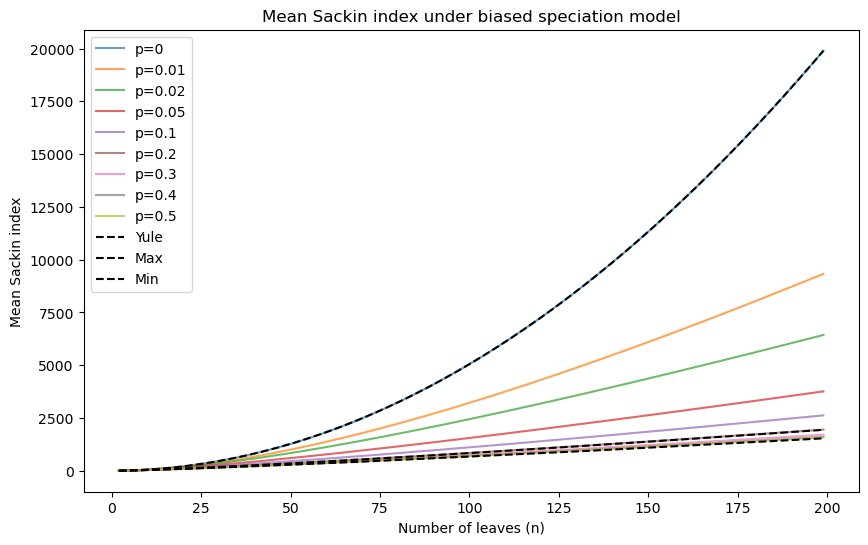

In [160]:
plt.figure(figsize=(10, 6))

p = [0, 0.01, 0.02, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5]


N = np.arange(2, 200)
for prob in p:
    means = [sackin_mean_const_p_stable(n, prob, digits = max(50, 1.5 * n)) for n in N]
    plt.plot(N, means, label=f"p={prob}", alpha = 0.7)

plt.plot(N, [sackin_yule(n) for n in N], label="Yule", linestyle='dashed', color='black')
plt.plot(N, [max_sackin(n) for n in N], label="Max", linestyle='dashed', color='black')
plt.plot(N, [min_sackin(n) for n in N], label="Min", linestyle='dashed', color='black')
plt.xlabel("Number of leaves (n)")
plt.ylabel("Mean Sackin index")
plt.title("Mean Sackin index under biased speciation model")
plt.legend()
plt.show()

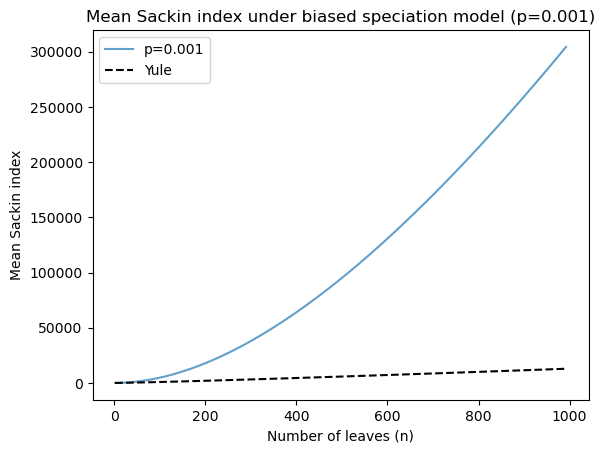

In [161]:
N = np.arange(2, 1000, 10)
p = 0.001
means = [sackin_mean_const_p_stable(n, p, digits = max(50, 1.5 * n)) for n in N]
plt.plot(N, means, label=f"p={p}", alpha = 0.7)
plt.plot(N, [sackin_yule(n) for n in N], label="Yule", linestyle='dashed', color='black')

plt.xlabel("Number of leaves (n)")
plt.ylabel("Mean Sackin index")
plt.title("Mean Sackin index under biased speciation model (p=0.001)")
plt.legend()
plt.show()

c:\Users\djbau\anaconda3\Lib\site-packages\matplotlib\cbook\__init__.py:1335: RuntimeWarning: overflow encountered in cast
  return np.asarray(x, float)


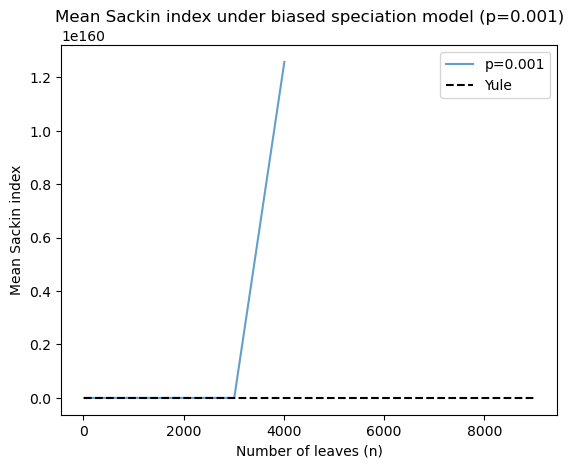

In [165]:
N = np.arange(10, 10000, 1000)
p = 0.001
means = [sackin_mean_const_p_stable(n, p, digits = max(30, n/10)) for n in N]
plt.plot(N, means, label=f"p={p}", alpha = 0.7)
plt.plot(N, [sackin_yule(n) for n in N], label="Yule", linestyle='dashed', color='black')

plt.xlabel("Number of leaves (n)")
plt.ylabel("Mean Sackin index")
plt.title("Mean Sackin index under biased speciation model (p=0.001)")
plt.legend()
plt.show()

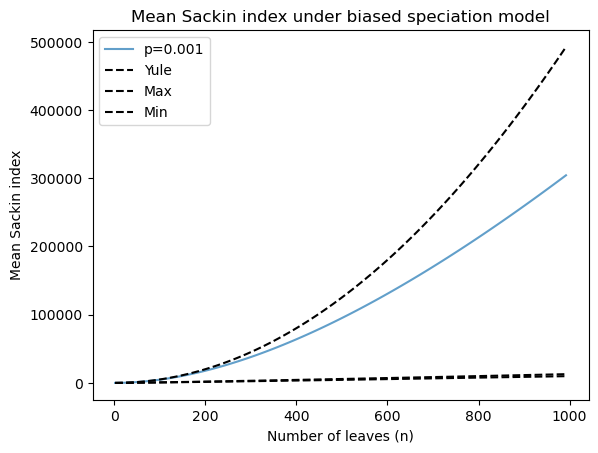

In [162]:
plt.plot(N, np.array(means), label=f"p={p}", alpha = 0.7)
plt.plot(N, [sackin_yule(n) for n in N], label="Yule", linestyle='dashed', color='black')
plt.plot(N, [max_sackin(n) for n in N], label="Max", linestyle='dashed', color='black')
plt.plot(N, [min_sackin(n) for n in N], label="Min", linestyle='dashed', color='black')
plt.xlabel("Number of leaves (n)")
plt.ylabel("Mean Sackin index")
plt.title("Mean Sackin index under biased speciation model")
plt.legend()
plt.show()

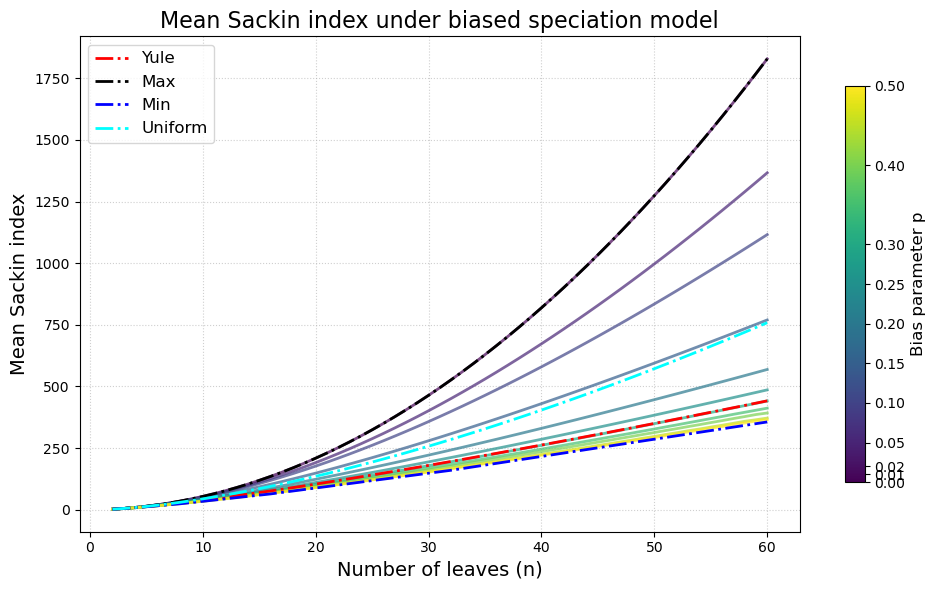

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm

plt.figure(figsize=(10, 6))

p = [0, 0.01, 0.02, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5]
N = np.arange(2, 61)

# Use a colormap for probabilities
colors = cm.viridis(np.linspace(0, 1, len(p)))

for prob, color in zip(p, colors):
    means = [sackin_constant_p(n, prob) for n in N]
    plt.plot(N, means, color=color, alpha=0.7, lw=2)

# Add reference models
plt.plot(N, [sackin_yule(n) for n in N], 
         label="Yule", linestyle='-.', color='red', linewidth=2)
plt.plot(N, [max_sackin(n) for n in N], 
         label="Max", linestyle='-.', color='black', linewidth=2)
plt.plot(N, [min_sackin(n) for n in N], 
         label="Min", linestyle='-.', color='blue', linewidth=2)
plt.plot(N, [sackin_uniform(n) for n in N], 
         label="Uniform", linestyle='-.', color='aqua', linewidth=2)

# Labels and title
plt.xlabel("Number of leaves (n)", fontsize=14)
plt.ylabel("Mean Sackin index", fontsize=14)
plt.title("Mean Sackin index under biased speciation model", fontsize=16)

# Colorbar for p values
sm = cm.ScalarMappable(cmap=cm.viridis, 
                       norm=plt.Normalize(vmin=min(p), vmax=max(p)))
sm.set_array([])
cbar = plt.colorbar(sm, ticks=p, shrink=0.8, ax=plt.gca())
cbar.set_label("Bias parameter p", fontsize=12)

# Legend only for reference lines
plt.legend(fontsize=12, loc="upper left")

# Grid and layout
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

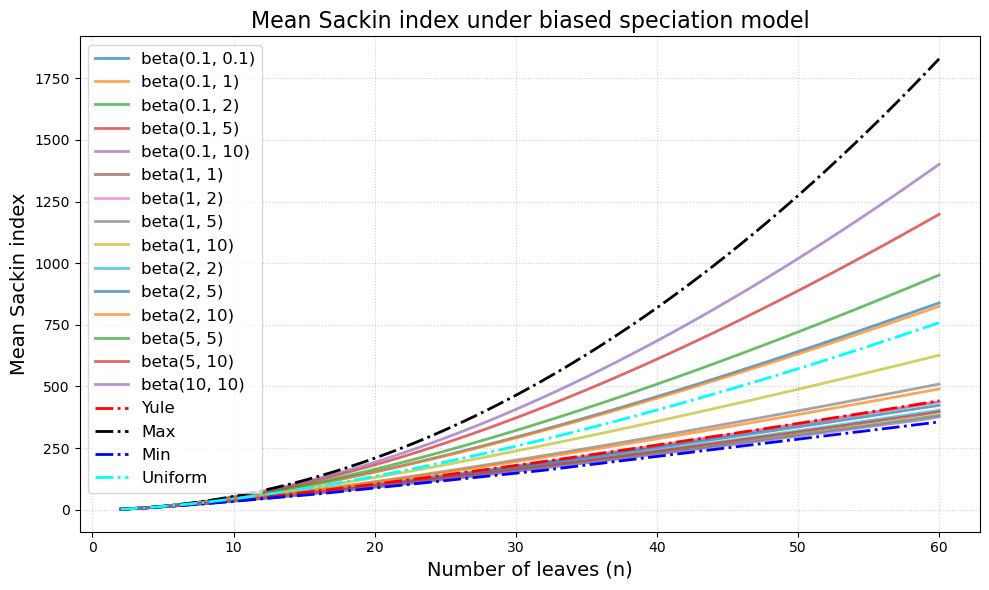

In [4]:
# Now make analogous plot for Beta(a,b)
a = [0.1, 1, 2, 5, 10]
b = [0.1, 1, 2, 5, 10]


plt.figure(figsize=(10, 6))
for (i, ai) in enumerate(a):
    for (j, bi) in enumerate(b):
        if i > j:
            continue
        means = [sackin_beta(n, ai, bi) for n in N]
        plt.plot(N, means, alpha=0.7, lw=2, label=f"beta({ai}, {bi})")

# Add reference models
plt.plot(N, [sackin_yule(n) for n in N], 
         label="Yule", linestyle='-.', color='red', linewidth=2)
plt.plot(N, [max_sackin(n) for n in N], 
         label="Max", linestyle='-.', color='black', linewidth=2)
plt.plot(N, [min_sackin(n) for n in N], 
         label="Min", linestyle='-.', color='blue', linewidth=2)
plt.plot(N, [sackin_uniform(n) for n in N], 
         label="Uniform", linestyle='-.', color='aqua', linewidth=2)

# Labels and title
plt.xlabel("Number of leaves (n)", fontsize=14)
plt.ylabel("Mean Sackin index", fontsize=14)
plt.title("Mean Sackin index under biased speciation model", fontsize=16)
plt.legend(fontsize=12, loc="upper left")


# Grid and layout

plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

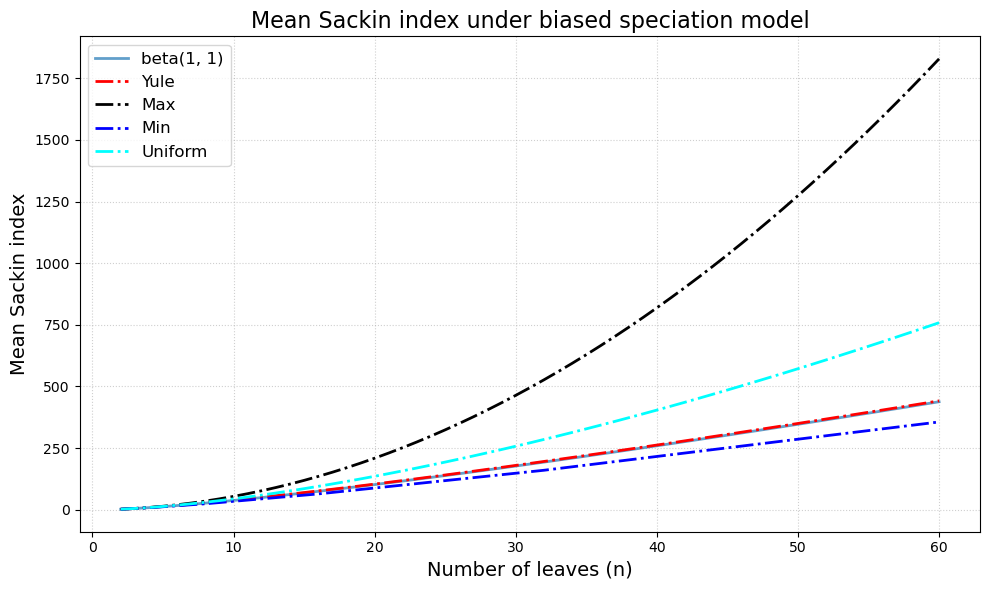

In [5]:
# Just do a = b = 1
plt.figure(figsize=(10, 6))
means = [sackin_beta(n, 1, 1) for n in N]
plt.plot(N, means, alpha=0.7, lw=2, label=f"beta(1, 1)")


# Add reference models
plt.plot(N, [sackin_yule(n) for n in N], 
         label="Yule", linestyle='-.', color='red', linewidth=2)
plt.plot(N, [max_sackin(n) for n in N], 
         label="Max", linestyle='-.', color='black', linewidth=2)
plt.plot(N, [min_sackin(n) for n in N], 
         label="Min", linestyle='-.', color='blue', linewidth=2)
plt.plot(N, [sackin_uniform(n) for n in N], 
         label="Uniform", linestyle='-.', color='aqua', linewidth=2)

# Labels and title
plt.xlabel("Number of leaves (n)", fontsize=14)
plt.ylabel("Mean Sackin index", fontsize=14)
plt.title("Mean Sackin index under biased speciation model", fontsize=16)
plt.legend(fontsize=12, loc="upper left")


# Grid and layout

plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()